# 02 Optimizacion

Este notebook construye el problema completo de optimizacion y ejecuta los dos metodos principales del proyecto:
- ACO
- Algoritmo genetico

La logica reusable vive en `src/`. El notebook solo orquesta, documenta y muestra resultados.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria')

In [2]:
from dataclasses import asdict
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config_modelo_costo import model_metadata
from src.core_grafo import load_city_index_to_name, save_json
from src.core_matrices import build_complete_matrices
from src.core_paths import ACO_OUTPUT_DIR, GA_OUTPUT_DIR, INPUT_COST_MATRIX_PATH, WEIGHTED_EDGES_CSV_PATH
from src.core_tsp_aco import ACOConfig, run_aco
from src.core_tsp_ga import GAConfig, run_ga

def load_json(path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return json.load(handle)

def show_table(title, df, columns=None, sort_by=None, ascending=True, precision=4):
    table = df.copy()
    if columns is not None:
        table = table.reindex(columns=columns)
    if sort_by is not None:
        table = table.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    display(Markdown(f'### {title}'))
    display(table.fillna('-').style.format(precision=precision))


## 1. Construccion de matrices completas

A partir del grafo ponderado de conexiones directas se construyen las matrices de costos minimos y la matriz de siguiente salto para reconstruccion de rutas.

In [3]:
matrices = build_complete_matrices()
matrices['summary']

{'ciudades': 96,
 'shape': [96, 96],
 'costo_minimo_finito': 11.968667,
 'costo_maximo_finito': 759.442332,
 'costo_promedio_finito': 232.18437044078948,
 'diagonal_cero': True,
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02',
 'vehiculo_referencia': {'name': 'Renault Clio',
  'fuel_type': 'gasolina',
  'segment': 'compacto',
  'note': 'Vehiculo de referencia para justificar el recorrido. El componente de combustible se toma desde la columna gasolina(euros) del dataset.'},
 'tarifa_vendedor_eur_h': 12.02,
 'salario_referencia': 'SMIC Francia 2026'}

In [4]:
cost_matrix = matrices['cost_matrix']
print('Shape matriz completa:', cost_matrix.shape)
print('Costo minimo finito:', np.min(cost_matrix[np.isfinite(cost_matrix)]))
print('Costo maximo finito:', np.max(cost_matrix[np.isfinite(cost_matrix)]))

Shape matriz completa: (96, 96)
Costo minimo finito: 0.0
Costo maximo finito: 759.442332


In [5]:
city_name_map = load_city_index_to_name(WEIGHTED_EDGES_CSV_PATH)
city_names = [city_name_map[index] for index in range(cost_matrix.shape[0])]
df_cost_preview = pd.DataFrame(cost_matrix, index=city_names, columns=city_names)
df_cost_preview.iloc[:5, :5]

,Bourg-en-Bresse,Laon,Moulins,Digne-les-Bains,Gap
Bourg-en-Bresse,0.000000,222.440001,89.836000,186.296001,147.731334
Laon,222.440001,0.000000,188.506000,402.643334,364.078667
Moulins,89.836000,188.506000,0.000000,237.889000,199.324333
Digne-les-Bains,186.296001,402.643334,237.889000,0.000000,38.564667
Gap,147.731334,364.078667,199.324333,38.564667,0.000000


## 2. Validacion de la matriz TSP

La matriz consolidada ya sale lista para TSP: es cuadrada, tiene diagonal en cero y mantiene costos finitos fuera de la diagonal.

In [6]:
print('Shape matriz TSP:', cost_matrix.shape)
print('Diagonal cero:', np.allclose(np.diag(cost_matrix), 0.0))
print('Finita fuera diagonal:', np.isfinite(cost_matrix[~np.eye(cost_matrix.shape[0], dtype=bool)]).all())

Shape matriz TSP: (96, 96)
Diagonal cero: True
Finita fuera diagonal: True


In [7]:
aco_matrix = np.load(INPUT_COST_MATRIX_PATH)
print('Shape matriz TSP cargada desde disco:', aco_matrix.shape)
print('Coincide con la matriz construida:', np.allclose(aco_matrix, cost_matrix))

Shape matriz TSP cargada desde disco: (96, 96)
Coincide con la matriz construida: True


## 3. Ejecucion de ACO

Se corre la colonia de hormigas sobre la matriz completa preparada.

In [8]:
aco_config = ACOConfig()
best_tour_aco, best_cost_aco, history_aco = run_aco(aco_matrix, aco_config)

aco_result = {
    'configuracion_aco': asdict(aco_config),
    'shape_matriz': list(aco_matrix.shape),
    'mejor_costo_tour': round(best_cost_aco, 6),
    'mejor_tour_indices': best_tour_aco,
    'mejor_tour_indices_sin_cierre': best_tour_aco[:-1],
    'mejor_tour_nombres': [city_names[index] for index in best_tour_aco],
    'mejor_tour_nombres_sin_cierre': [city_names[index] for index in best_tour_aco[:-1]],
    'historial_mejor_costo': [round(value, 6) for value in history_aco],
}
aco_result.update(model_metadata())

aco_summary = {
    'mejor_costo_tour': round(best_cost_aco, 6),
    'iteraciones': aco_config.iterations,
    'hormigas': aco_config.ants,
    'seed': aco_config.seed,
    'n_ciudades': len(best_tour_aco) - 1,
    'tour_cerrado': len(best_tour_aco),
}
aco_summary.update(model_metadata())

save_json(ACO_OUTPUT_DIR / 'resultado_aco_final.json', aco_result)
save_json(ACO_OUTPUT_DIR / 'resumen_aco_final.json', aco_summary)

aco_summary

{'mejor_costo_tour': 4471.569332,
 'iteraciones': 250,
 'hormigas': 40,
 'seed': 42,
 'n_ciudades': 96,
 'tour_cerrado': 97,
 'vehiculo_referencia': {'name': 'Renault Clio',
  'fuel_type': 'gasolina',
  'segment': 'compacto',
  'note': 'Vehiculo de referencia para justificar el recorrido. El componente de combustible se toma desde la columna gasolina(euros) del dataset.'},
 'tarifa_vendedor_eur_h': 12.02,
 'salario_referencia': 'SMIC Francia 2026',
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

### Experimento cambiando numero de hormigas

In [32]:
experimentos_aco = [
    {"nombre": "ants_10", "params": {"ants": 40, "iterations": 60}},
    {"nombre": "ants_20", "params": {"ants": 60, "iterations": 60}},
    {"nombre": "ants_40", "params": {"ants": 100, "iterations": 60}},
    {"nombre": "ants_60", "params": {"ants": 150, "iterations": 60}},
    {"nombre": "ants_80", "params": {"ants": 250, "iterations": 60}},
]

historiales_aco = []
resumenes_aco = []

for experimento in experimentos_aco:
    nombre = experimento["nombre"]
    params = experimento["params"]

    aco_config = ACOConfig(**params)
    best_tour_aco, best_cost_aco, history_aco = run_aco(aco_matrix, aco_config)

    resumenes_aco.append({
        "experimento": nombre,
        "hormigas": aco_config.ants,
        "mejor_costo_tour": round(best_cost_aco, 6),
        "iteraciones": aco_config.iterations,
        "seed": aco_config.seed,
    })

    for i, costo in enumerate(history_aco, start=1):
        historiales_aco.append({
            "experimento": nombre,
            "hormigas": aco_config.ants,
            "iteracion": i,
            "mejor_costo": round(costo, 6),
        })

df_historial_aco = pd.DataFrame(historiales_aco)
df_resumen_aco = pd.DataFrame(resumenes_aco)



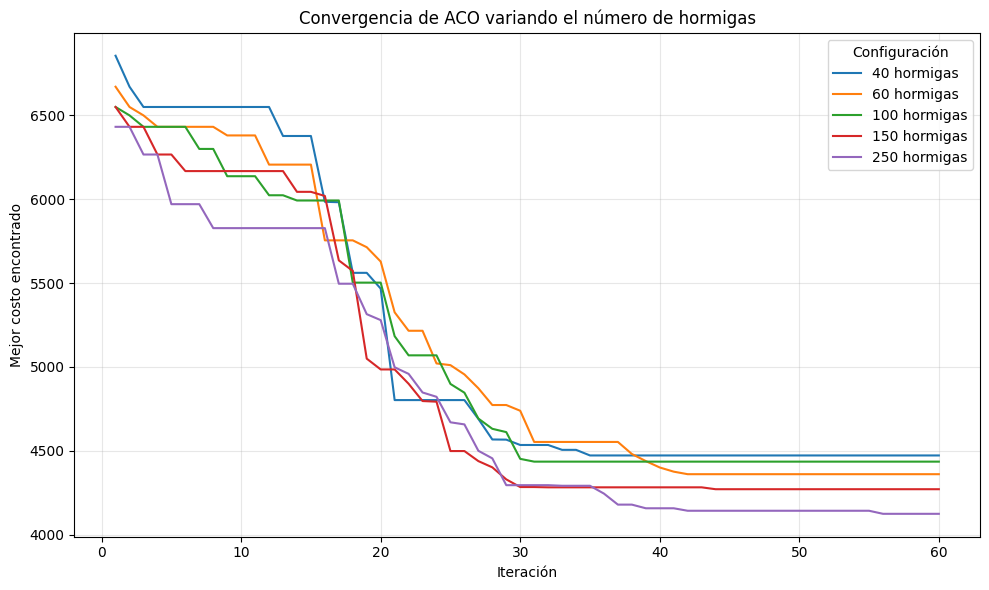

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for hormigas, grupo in df_historial_aco.groupby("hormigas"):
    grupo = grupo.sort_values("iteracion")
    plt.plot(
        grupo["iteracion"],
        grupo["mejor_costo"],
        label=f"{hormigas} hormigas"
    )

plt.xlabel("Iteración")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de ACO variando el número de hormigas")
plt.legend(title="Configuración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
EXPERIMENTOS_ACO_DIR = ACO_OUTPUT_DIR / "experimentos" / "ants"
EXPERIMENTOS_ACO_DIR.mkdir(parents=True, exist_ok=True)

df_historial_aco.to_csv(EXPERIMENTOS_ACO_DIR / "historial_experimentos_ants.csv", index=False)
df_resumen_aco.to_csv(EXPERIMENTOS_ACO_DIR / "resumen_experimentos_ants.csv", index=False)

save_json(
    EXPERIMENTOS_ACO_DIR / "experimentos_ants.json",
    {
        "historial": df_historial_aco.to_dict(orient="records"),
        "resumen": df_resumen_aco.to_dict(orient="records"),
    },
)

print("Guardado en:", EXPERIMENTOS_ACO_DIR)

Guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\aco\experimentos\ants


### Experimento cambiando el beta

In [24]:
experimentos_aco = [
    {"nombre": "beta_1", "params": {"beta": 3.0, "iterations": 60}},
    {"nombre": "beta_2", "params": {"beta": 4.0, "iterations": 60}},
    {"nombre": "beta_3", "params": {"beta": 5.0, "iterations": 60}},
    {"nombre": "beta_4", "params": {"beta": 6.0, "iterations": 60}},
    {"nombre": "beta_5", "params": {"beta": 7.0, "iterations": 60}},
]

historiales_aco = []
resumenes_aco = []

for experimento in experimentos_aco:
    nombre = experimento["nombre"]
    params = experimento["params"]

    aco_config = ACOConfig(**params)
    best_tour_aco, best_cost_aco, history_aco = run_aco(aco_matrix, aco_config)

    resumenes_aco.append({
        "experimento": nombre,
        "beta": aco_config.beta,
        "hormigas": aco_config.ants,
        "mejor_costo_tour": round(best_cost_aco, 6),
        "iteraciones": aco_config.iterations,
        "seed": aco_config.seed,
    })

    for i, costo in enumerate(history_aco, start=1):
        historiales_aco.append({
            "experimento": nombre,
            "beta": aco_config.beta,
            "hormigas": aco_config.ants,
            "iteracion": i,
            "mejor_costo": round(costo, 6),
        })

df_historial_aco = pd.DataFrame(historiales_aco)
df_resumen_aco = pd.DataFrame(resumenes_aco)

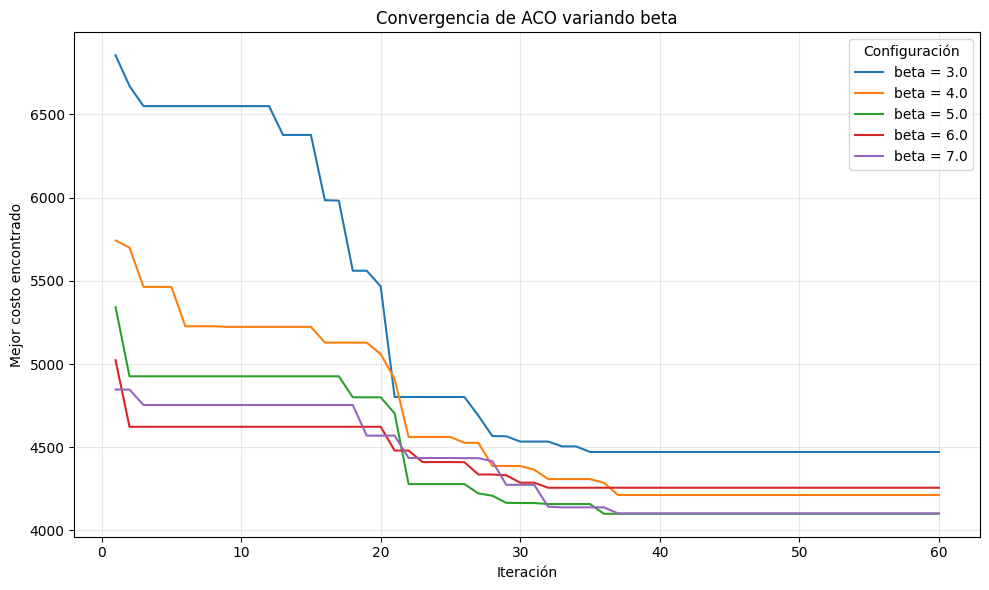

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for beta, grupo in df_historial_aco.groupby("beta"):
    grupo = grupo.sort_values("iteracion")
    plt.plot(
        grupo["iteracion"],
        grupo["mejor_costo"],
        label=f"beta = {beta}"
    )

plt.xlabel("Iteración")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de ACO variando beta")
plt.legend(title="Configuración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
EXPERIMENTOS_ACO_DIR = ACO_OUTPUT_DIR / "experimentos"
EXPERIMENTOS_ACO_DIR.mkdir(parents=True, exist_ok=True)

df_historial_aco.to_csv(EXPERIMENTOS_ACO_DIR / "historial_experimentos_beta.csv", index=False)
df_resumen_aco.to_csv(EXPERIMENTOS_ACO_DIR / "resumen_experimentos_beta.csv", index=False)

save_json(
    EXPERIMENTOS_ACO_DIR / "experimentos_beta.json",
    {
        "historial": df_historial_aco.to_dict(orient="records"),
        "resumen": df_resumen_aco.to_dict(orient="records"),
    },
)

print("Guardado en:", EXPERIMENTOS_ACO_DIR)

Guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\aco\experimentos


### Evaporation Rate

In [29]:
experimentos_aco = [
    {"nombre": "evap_015", "params": {"evaporation_rate": 0.15, "iterations": 100}},
    {"nombre": "evap_025", "params": {"evaporation_rate": 0.25, "iterations": 100}},
    {"nombre": "evap_035", "params": {"evaporation_rate": 0.35, "iterations": 100}},
    {"nombre": "evap_045", "params": {"evaporation_rate": 0.45, "iterations": 100}},
    {"nombre": "evap_055", "params": {"evaporation_rate": 0.55, "iterations": 100}},
]

historiales_aco = []
resumenes_aco = []

for experimento in experimentos_aco:
    nombre = experimento["nombre"]
    params = experimento["params"]

    aco_config = ACOConfig(**params)
    best_tour_aco, best_cost_aco, history_aco = run_aco(aco_matrix, aco_config)

    resumenes_aco.append({
        "experimento": nombre,
        "evaporation_rate": aco_config.evaporation_rate,
        "hormigas": aco_config.ants,
        "mejor_costo_tour": round(best_cost_aco, 6),
        "iteraciones": aco_config.iterations,
        "seed": aco_config.seed,
    })

    for i, costo in enumerate(history_aco, start=1):
        historiales_aco.append({
            "experimento": nombre,
            "evaporation_rate": aco_config.evaporation_rate,
            "hormigas": aco_config.ants,
            "iteracion": i,
            "mejor_costo": round(costo, 6),
        })

df_historial_aco = pd.DataFrame(historiales_aco)
df_resumen_aco = pd.DataFrame(resumenes_aco)

df_resumen_aco.sort_values("mejor_costo_tour")

,experimento,evaporation_rate,hormigas,mejor_costo_tour,iteraciones,seed
1,evap_025,0.25,40,4067.228332,100,42
0,evap_015,0.15,40,4274.693667,100,42
2,evap_035,0.35,40,4471.569332,100,42
3,evap_045,0.45,40,4481.515666,100,42
4,evap_055,0.55,40,4721.023999,100,42


In [31]:
EXPERIMENTOS_ACO_DIR = ACO_OUTPUT_DIR / "experimentos"
EXPERIMENTOS_ACO_DIR.mkdir(parents=True, exist_ok=True)

df_historial_aco.to_csv(EXPERIMENTOS_ACO_DIR / "historial_experimentos_evaporation_rate.csv", index=False)
df_resumen_aco.to_csv(EXPERIMENTOS_ACO_DIR / "resumen_experimentos_evaporation_rate.csv", index=False)

save_json(
    EXPERIMENTOS_ACO_DIR / "experimentos_evaporation_rate.json",
    {
        "historial": df_historial_aco.to_dict(orient="records"),
        "resumen": df_resumen_aco.to_dict(orient="records"),
    },
)

print("Guardado en:", EXPERIMENTOS_ACO_DIR)

Guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\aco\experimentos


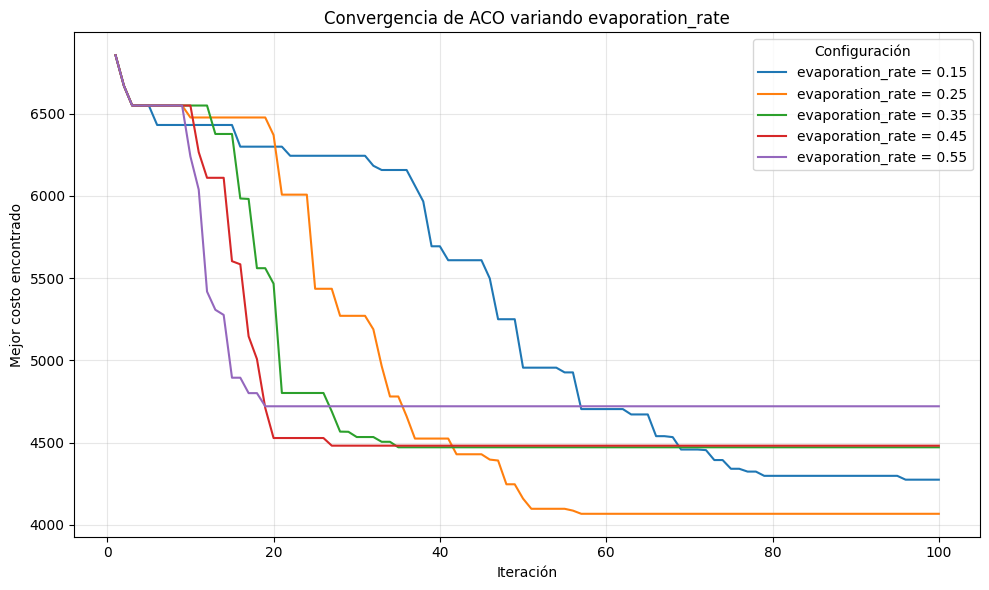

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for evap, grupo in df_historial_aco.groupby("evaporation_rate"):
    grupo = grupo.sort_values("iteracion")
    plt.plot(
        grupo["iteracion"],
        grupo["mejor_costo"],
        label=f"evaporation_rate = {evap}"
    )

plt.xlabel("Iteración")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de ACO variando evaporation_rate")
plt.legend(title="Configuración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Corriendo el mejor

In [53]:
aco_config = ACOConfig(
    ants=150,
    alpha=1.0,
    beta=5.0,
    evaporation_rate=0.25,
    intensification=2.0,
    elite_weight=2.0,
)

best_tour_aco, best_cost_aco, history_aco = run_aco(aco_matrix, aco_config)

aco_result = {
    'configuracion_aco': asdict(aco_config),
    'shape_matriz': list(aco_matrix.shape),
    'mejor_costo_tour': round(best_cost_aco, 6),
    'mejor_tour_indices': best_tour_aco,
    'mejor_tour_indices_sin_cierre': best_tour_aco[:-1],
    'mejor_tour_nombres': [city_names[index] for index in best_tour_aco],
    'mejor_tour_nombres_sin_cierre': [city_names[index] for index in best_tour_aco[:-1]],
    'historial_mejor_costo': [round(value, 6) for value in history_aco],
}
aco_result.update(model_metadata())

aco_summary = {
    'mejor_costo_tour': round(best_cost_aco, 6),
    'iteraciones': aco_config.iterations,
    'hormigas': aco_config.ants,
    'alpha': aco_config.alpha,
    'beta': aco_config.beta,
    'evaporation_rate': aco_config.evaporation_rate,
    'intensification': aco_config.intensification,
    'elite_weight': aco_config.elite_weight,
    'seed': aco_config.seed,
    'n_ciudades': len(best_tour_aco) - 1,
    'tour_cerrado': len(best_tour_aco),
}
aco_summary.update(model_metadata())

save_json(ACO_OUTPUT_DIR / 'resultado_aco_final.json', aco_result)
save_json(ACO_OUTPUT_DIR / 'resumen_aco_final.json', aco_summary)

aco_summary

{'mejor_costo_tour': 4022.039333,
 'iteraciones': 250,
 'hormigas': 150,
 'alpha': 1.0,
 'beta': 5.0,
 'evaporation_rate': 0.25,
 'intensification': 2.0,
 'elite_weight': 2.0,
 'seed': 42,
 'n_ciudades': 96,
 'tour_cerrado': 97,
 'vehiculo_referencia': {'name': 'Renault Clio',
  'fuel_type': 'gasolina',
  'segment': 'compacto',
  'note': 'Vehiculo de referencia para justificar el recorrido. El componente de combustible se toma desde la columna gasolina(euros) del dataset.'},
 'tarifa_vendedor_eur_h': 12.02,
 'salario_referencia': 'SMIC Francia 2026',
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

In [54]:
pd.DataFrame({'iteracion': range(1, len(history_aco) + 1), 'mejor_costo': history_aco}).head()

,iteracion,mejor_costo
0,1,4926.211668
1,2,4926.211668
2,3,4926.211668
3,4,4926.211668
4,5,4926.211668


## 4. Ejecucion del algoritmo genetico

Se corre GA sobre la misma matriz. Si existe un resultado ACO, se usa como semilla inicial cuando la configuracion lo permite.

## Experimentos GA

### Mutation Rate

In [37]:
experimentos_ga = [
    {"nombre": "mut_012", "params": {"mutation_rate": 0.12}},
    {"nombre": "mut_016", "params": {"mutation_rate": 0.16}},
    {"nombre": "mut_020", "params": {"mutation_rate": 0.20}},
    {"nombre": "mut_024", "params": {"mutation_rate": 0.24}},
    {"nombre": "mut_028", "params": {"mutation_rate": 0.28}},
]

historiales_ga = []
resumenes_ga = []

for experimento in experimentos_ga:
    nombre = experimento["nombre"]
    params = experimento["params"]

    ga_config = GAConfig(**params)
    best_tour_ga, best_cost_ga, history_ga = run_ga(
        aco_matrix,
        ga_config,
        ACO_OUTPUT_DIR / "resultado_aco_final.json",
    )

    resumenes_ga.append({
        "experimento": nombre,
        "mutation_rate": ga_config.mutation_rate,
        "tam_poblacion": ga_config.population_size,
        "generaciones": ga_config.generations,
        "elite_count": ga_config.elite_count,
        "tournament_size": ga_config.tournament_size,
        "crossover_rate": ga_config.crossover_rate,
        "inject_aco_seed": ga_config.inject_aco_seed,
        "mejor_costo_tour": round(best_cost_ga, 6),
        "seed": ga_config.seed,
    })

    for i, costo in enumerate(history_ga, start=1):
        historiales_ga.append({
            "experimento": nombre,
            "mutation_rate": ga_config.mutation_rate,
            "generacion": i,
            "mejor_costo": round(costo, 6),
        })

df_historial_ga = pd.DataFrame(historiales_ga)
df_resumen_ga = pd.DataFrame(resumenes_ga)

df_resumen_ga.sort_values("mejor_costo_tour")

,experimento,mutation_rate,tam_poblacion,generaciones,elite_count,tournament_size,crossover_rate,inject_aco_seed,mejor_costo_tour,seed
0,mut_012,0.12,180,350,12,5,0.9,True,3975.266333,42
1,mut_016,0.16,180,350,12,5,0.9,True,3975.266333,42
2,mut_020,0.20,180,350,12,5,0.9,True,3975.266333,42
3,mut_024,0.24,180,350,12,5,0.9,True,3975.266333,42
4,mut_028,0.28,180,350,12,5,0.9,True,3975.266333,42


In [38]:
EXPERIMENTOS_GA_DIR = GA_OUTPUT_DIR / "experimentos"
EXPERIMENTOS_GA_DIR.mkdir(parents=True, exist_ok=True)

df_historial_ga.to_csv(EXPERIMENTOS_GA_DIR / "historial_experimentos_mutation_rate.csv", index=False)
df_resumen_ga.to_csv(EXPERIMENTOS_GA_DIR / "resumen_experimentos_mutation_rate.csv", index=False)

save_json(
    EXPERIMENTOS_GA_DIR / "experimentos_mutation_rate.json",
    {
        "historial": df_historial_ga.to_dict(orient="records"),
        "resumen": df_resumen_ga.to_dict(orient="records"),
    },
)

print("Guardado en:", EXPERIMENTOS_GA_DIR)

Guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\ga\experimentos


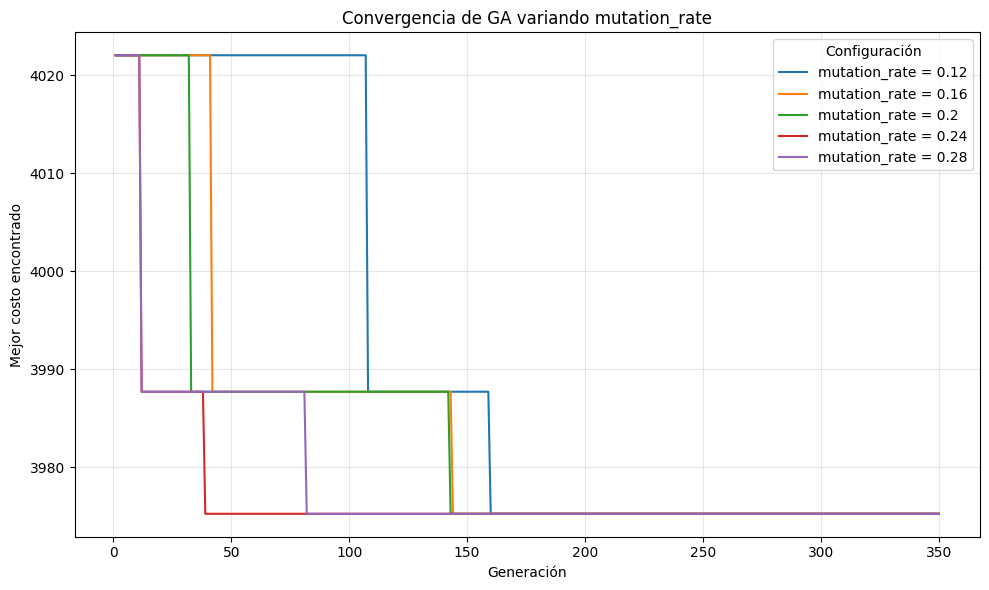

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for mut, grupo in df_historial_ga.groupby("mutation_rate"):
    grupo = grupo.sort_values("generacion")
    plt.plot(
        grupo["generacion"],
        grupo["mejor_costo"],
        label=f"mutation_rate = {mut}"
    )

plt.xlabel("Generación")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de GA variando mutation_rate")
plt.legend(title="Configuración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### population_size

In [40]:
experimentos_ga = [
    {"nombre": "pop_180", "params": {"population_size": 180}},
    {"nombre": "pop_220", "params": {"population_size": 220}},
    {"nombre": "pop_260", "params": {"population_size": 260}},
    {"nombre": "pop_300", "params": {"population_size": 300}},
    {"nombre": "pop_340", "params": {"population_size": 340}},
]

historiales_ga = []
resumenes_ga = []

for experimento in experimentos_ga:
    nombre = experimento["nombre"]
    params = experimento["params"]

    ga_config = GAConfig(**params)
    best_tour_ga, best_cost_ga, history_ga = run_ga(
        aco_matrix,
        ga_config,
        ACO_OUTPUT_DIR / "resultado_aco_final.json",
    )

    resumenes_ga.append({
        "experimento": nombre,
        "population_size": ga_config.population_size,
        "mutation_rate": ga_config.mutation_rate,
        "generaciones": ga_config.generations,
        "elite_count": ga_config.elite_count,
        "tournament_size": ga_config.tournament_size,
        "crossover_rate": ga_config.crossover_rate,
        "inject_aco_seed": ga_config.inject_aco_seed,
        "mejor_costo_tour": round(best_cost_ga, 6),
        "seed": ga_config.seed,
    })

    for i, costo in enumerate(history_ga, start=1):
        historiales_ga.append({
            "experimento": nombre,
            "population_size": ga_config.population_size,
            "generacion": i,
            "mejor_costo": round(costo, 6),
        })

df_historial_ga = pd.DataFrame(historiales_ga)
df_resumen_ga = pd.DataFrame(resumenes_ga)

df_resumen_ga.sort_values("mejor_costo_tour")

,experimento,population_size,mutation_rate,generaciones,elite_count,tournament_size,crossover_rate,inject_aco_seed,mejor_costo_tour,seed
0,pop_180,180,0.12,350,12,5,0.9,True,3975.266333,42
1,pop_220,220,0.12,350,12,5,0.9,True,3975.266333,42
2,pop_260,260,0.12,350,12,5,0.9,True,3975.266333,42
3,pop_300,300,0.12,350,12,5,0.9,True,3975.266333,42
4,pop_340,340,0.12,350,12,5,0.9,True,3975.266333,42


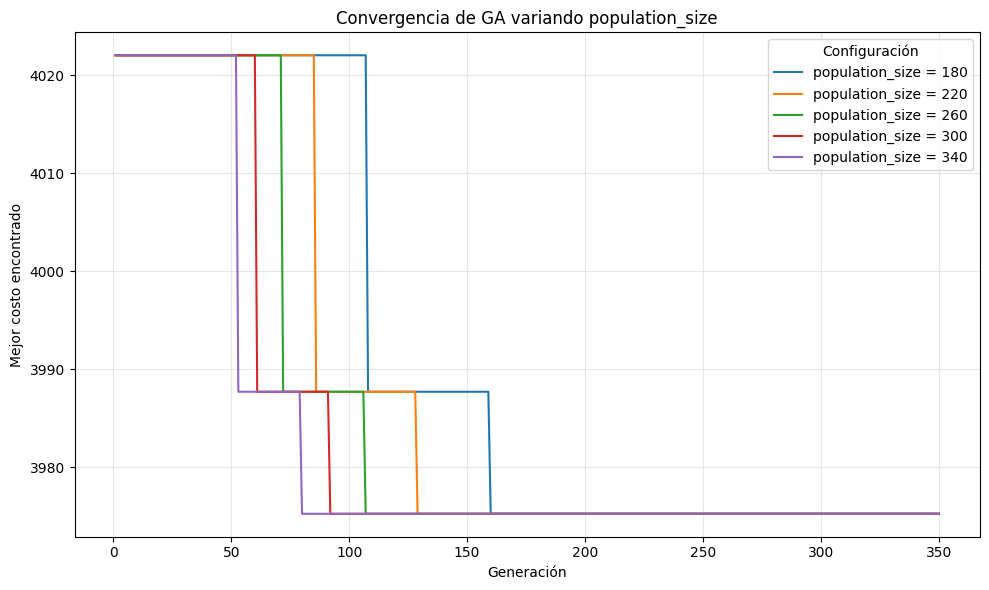

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for pop, grupo in df_historial_ga.groupby("population_size"):
    grupo = grupo.sort_values("generacion")
    plt.plot(
        grupo["generacion"],
        grupo["mejor_costo"],
        label=f"population_size = {pop}"
    )

plt.xlabel("Generación")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de GA variando population_size")
plt.legend(title="Configuración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
EXPERIMENTOS_GA_DIR = GA_OUTPUT_DIR / "experimentos" / "population_size"
EXPERIMENTOS_GA_DIR.mkdir(parents=True, exist_ok=True)

df_historial_ga.to_csv(EXPERIMENTOS_GA_DIR / "historial_experimentos_population_size.csv", index=False)
df_resumen_ga.to_csv(EXPERIMENTOS_GA_DIR / "resumen_experimentos_population_size.csv", index=False)

save_json(
    EXPERIMENTOS_GA_DIR / "experimentos_population_size.json",
    {
        "historial": df_historial_ga.to_dict(orient="records"),
        "resumen": df_resumen_ga.to_dict(orient="records"),
    },
)

print("Guardado en:", EXPERIMENTOS_GA_DIR)

Guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\ga\experimentos\population_size


### inject_aco_seed

In [43]:
experimentos_ga = [
    {"nombre": "seed_aco_true", "params": {"inject_aco_seed": True, "generations": 200}},
    {"nombre": "seed_aco_false", "params": {"inject_aco_seed": False, "generations": 200}},
]

historiales_ga = []
resumenes_ga = []

for experimento in experimentos_ga:
    nombre = experimento["nombre"]
    params = experimento["params"]

    ga_config = GAConfig(**params)
    best_tour_ga, best_cost_ga, history_ga = run_ga(
        aco_matrix,
        ga_config,
        ACO_OUTPUT_DIR / "resultado_aco_final.json",
    )

    resumenes_ga.append({
        "experimento": nombre,
        "inject_aco_seed": ga_config.inject_aco_seed,
        "population_size": ga_config.population_size,
        "mutation_rate": ga_config.mutation_rate,
        "generaciones": ga_config.generations,
        "elite_count": ga_config.elite_count,
        "tournament_size": ga_config.tournament_size,
        "crossover_rate": ga_config.crossover_rate,
        "mejor_costo_tour": round(best_cost_ga, 6),
        "seed": ga_config.seed,
    })

    for i, costo in enumerate(history_ga, start=1):
        historiales_ga.append({
            "experimento": nombre,
            "inject_aco_seed": ga_config.inject_aco_seed,
            "generacion": i,
            "mejor_costo": round(costo, 6),
        })

df_historial_ga = pd.DataFrame(historiales_ga)
df_resumen_ga = pd.DataFrame(resumenes_ga)

df_resumen_ga.sort_values("mejor_costo_tour")

,experimento,inject_aco_seed,population_size,mutation_rate,generaciones,elite_count,tournament_size,crossover_rate,mejor_costo_tour,seed
0,seed_aco_true,True,180,0.12,200,12,5,0.9,3975.266333,42
1,seed_aco_false,False,180,0.12,200,12,5,0.9,7785.332996,42


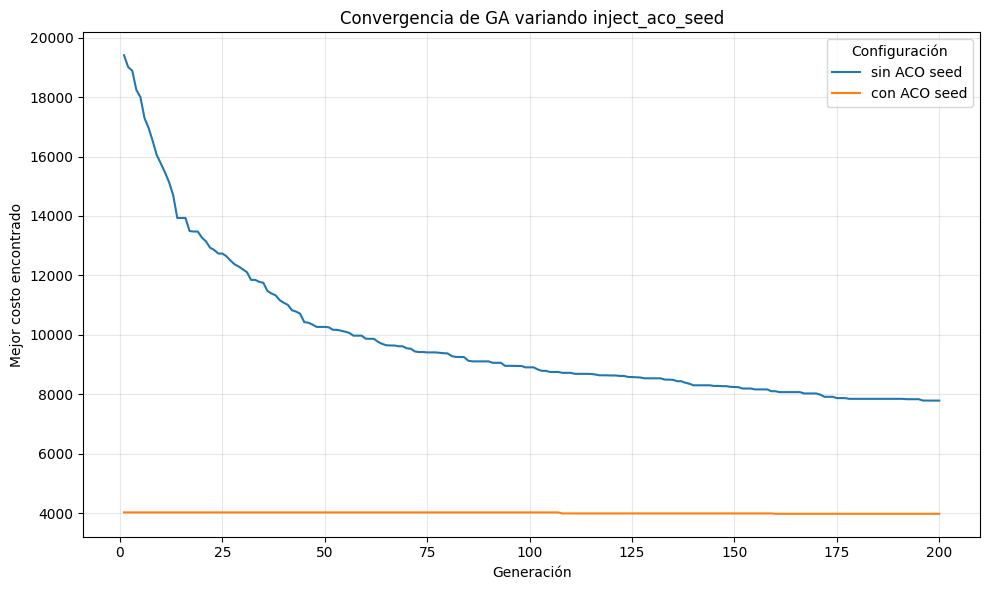

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for inject, grupo in df_historial_ga.groupby("inject_aco_seed"):
    grupo = grupo.sort_values("generacion")
    etiqueta = "con ACO seed" if inject else "sin ACO seed"
    plt.plot(
        grupo["generacion"],
        grupo["mejor_costo"],
        label=etiqueta
    )

plt.xlabel("Generación")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de GA variando inject_aco_seed")
plt.legend(title="Configuración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
EXPERIMENTOS_GA_DIR = GA_OUTPUT_DIR / "experimentos" / "inject_aco_seed"
EXPERIMENTOS_GA_DIR.mkdir(parents=True, exist_ok=True)

df_historial_ga.to_csv(EXPERIMENTOS_GA_DIR / "historial_experimentos_inject_aco_seed.csv", index=False)
df_resumen_ga.to_csv(EXPERIMENTOS_GA_DIR / "resumen_experimentos_inject_aco_seed.csv", index=False)

save_json(
    EXPERIMENTOS_GA_DIR / "experimentos_inject_aco_seed.json",
    {
        "historial": df_historial_ga.to_dict(orient="records"),
        "resumen": df_resumen_ga.to_dict(orient="records"),
    },
)

print("Guardado en:", EXPERIMENTOS_GA_DIR)

Guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\ga\experimentos\inject_aco_seed


### Ejecución Final

In [55]:
ga_config = GAConfig(
    population_size=300,
    mutation_rate=0.24,
    crossover_rate=0.9,
    elite_count=12,
    tournament_size=5,
    seed=42,
    start_node=0,
    inject_aco_seed=True,
)

best_tour_ga, best_cost_ga, history_ga = run_ga(
    aco_matrix,
    ga_config,
    ACO_OUTPUT_DIR / 'resultado_aco_final.json',
)

ga_result = {
    'configuracion_ga': asdict(ga_config),
    'shape_matriz': list(aco_matrix.shape),
    'mejor_costo_tour': round(best_cost_ga, 6),
    'mejor_tour_indices': best_tour_ga,
    'mejor_tour_indices_sin_cierre': best_tour_ga[:-1],
    'mejor_tour_nombres': [city_names[index] for index in best_tour_ga],
    'mejor_tour_nombres_sin_cierre': [city_names[index] for index in best_tour_ga[:-1]],
    'historial_mejor_costo': [round(value, 6) for value in history_ga],
}
ga_result.update(model_metadata())

ga_summary = {
    'mejor_costo_tour': round(best_cost_ga, 6),
    'generaciones': ga_config.generations,
    'tam_poblacion': ga_config.population_size,
    'seed': ga_config.seed,
    'n_ciudades': len(best_tour_ga) - 1,
    'tour_cerrado': len(best_tour_ga),
}
ga_summary.update(model_metadata())

save_json(GA_OUTPUT_DIR / 'resultado_ga_final.json', ga_result)
save_json(GA_OUTPUT_DIR / 'resumen_ga_final.json', ga_summary)

ga_summary

{'mejor_costo_tour': 3975.266333,
 'generaciones': 350,
 'tam_poblacion': 300,
 'seed': 42,
 'n_ciudades': 96,
 'tour_cerrado': 97,
 'vehiculo_referencia': {'name': 'Renault Clio',
  'fuel_type': 'gasolina',
  'segment': 'compacto',
  'note': 'Vehiculo de referencia para justificar el recorrido. El componente de combustible se toma desde la columna gasolina(euros) del dataset.'},
 'tarifa_vendedor_eur_h': 12.02,
 'salario_referencia': 'SMIC Francia 2026',
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

In [56]:
pd.DataFrame({'generacion': range(1, len(history_ga) + 1), 'mejor_costo': history_ga}).head()

,generacion,mejor_costo
0,1,4022.039333
1,2,4022.039333
2,3,4022.039333
3,4,4022.039333
4,5,4022.039333


## 5. Resumenes exportados en JSON

Se recargan los resumenes exportados por ambos metodos y se muestran como tablas legibles a partir de los archivos JSON guardados.

In [57]:
aco_summary_json = load_json(ACO_OUTPUT_DIR / 'resumen_aco_final.json')
ga_summary_json = load_json(GA_OUTPUT_DIR / 'resumen_ga_final.json')

df_resumenes = pd.concat([
    pd.json_normalize(aco_summary_json).assign(metodo='ACO'),
    pd.json_normalize(ga_summary_json).assign(metodo='GA'),
], ignore_index=True)

columnas = [
    'metodo',
    'mejor_costo_tour',
    'iteraciones',
    'hormigas',
    'generaciones',
    'tam_poblacion',
    'seed',
    'n_ciudades',
    'tour_cerrado',
    'tarifa_vendedor_eur_h',
    'salario_referencia',
]
show_table('Resumenes ACO y GA exportados', df_resumenes, columns=columnas, sort_by='mejor_costo_tour')

### Resumenes ACO y GA exportados

,metodo,mejor_costo_tour,iteraciones,hormigas,generaciones,tam_poblacion,seed,n_ciudades,tour_cerrado,tarifa_vendedor_eur_h,salario_referencia
0,GA,3975.2663,-,-,350.0000,300.0000,42,96,97,12.0200,SMIC Francia 2026
1,ACO,4022.0393,250.0000,150.0000,-,-,42,96,97,12.0200,SMIC Francia 2026


## 5. Comparacion rapida

Se deja una comparacion preliminar del costo final de ambos metodos. La visualizacion y seleccion final se desarrollaran en `03_resultados_finales.ipynb`.

In [58]:
comparison = pd.DataFrame([
    {'metodo': 'ACO', 'mejor_costo': best_cost_aco},
    {'metodo': 'GA', 'mejor_costo': best_cost_ga},
])
comparison['diferencia_vs_mejor'] = comparison['mejor_costo'] - comparison['mejor_costo'].min()
show_table('Comparacion rapida ACO vs GA', comparison, sort_by='mejor_costo')

### Comparacion rapida ACO vs GA

,metodo,mejor_costo,diferencia_vs_mejor
0,GA,3975.2663,0.0000
1,ACO,4022.0393,46.7730


In [59]:
ganador_provisional = df_resumenes.sort_values('mejor_costo_tour').iloc[0]
print(f"Metodo ganador provisional: {ganador_provisional['metodo']}")
print(f"Costo final: {ganador_provisional['mejor_costo_tour']}")
print(f"Seed: {ganador_provisional['seed']}")

Metodo ganador provisional: GA
Costo final: 3975.266333
Seed: 42


## Salida de esta etapa

Con esto queda listo el problema optimizado y quedan guardados los resultados base en:
- `data/processed`
- `outputs/aco`
- `outputs/ga`

El siguiente notebook se enfocara en expandir la mejor ruta, comparar formalmente ambos metodos y generar artefactos finales para la entrega y la web.